# **Project Name**    -  Mental Health in Tech Survey — Exploratory Data Analysis

##### **Project Type**    - EDA
##### **Contribution**    - Individual
##### **Team Member 1 -** *<your name here>*

# **Project Summary -**

Open Sourcing Mental Illness (OSMI) ran a survey in 2014 asking people who work in technology
how their workplace treats mental health. 1,259 people answered 27 questions covering who they
are (age, gender, country, company size), what their employer offers (insurance benefits, care
options, wellness programmes, anonymity guarantees, leave policy), and how safe they feel
actually using any of it (would they tell a coworker, a supervisor, an interviewer).

This notebook turns those 1,259 raw rows into a picture of where the tech industry was losing
people to untreated mental illness, and which employer levers moved the needle.

**Cleaning.** The raw file is messy in three specific ways. `Age` contains impossible values
(-1726 and 99999999999) that would destroy every mean and every axis, so the analysis is
restricted to ages 18-75. `Gender` is free text with 49 distinct spellings — "Male", "male",
"Cis Man", "Make", "Trans woman" — collapsed here into Male / Female / Non-binary & other.
`work_interfere` is blank for 264 people, but those blanks are not missing data: the question
only applies if you have a condition, so a blank is the answer "not applicable" and is kept as
its own category rather than dropped. `comments` is 87% empty free text and is dropped.
`self_employed` blanks are filled with "No" and `state` blanks with "Not in US". Nothing else is
deleted — the cleaned frame keeps 1,251 of 1,259 rows, so no cohort is silently thrown away.

**Feature engineering.** Two scores are derived. `Employer_Support_Score` (0-5) counts how many
of benefits / care options / wellness programme / seek-help resources / anonymity an employer
actually provides. `Openness_Score` (0-3) counts how many audiences — coworkers, supervisor,
interviewer — a respondent would talk to. These turn 8 scattered Yes/No columns into two
variables that can be plotted against outcomes.

**What the analysis finds.** Almost exactly half the sample (50.5%) has sought treatment, which
means the "rare edge case" framing employers used in 2014 was wrong by an order of magnitude.
Family history is the strongest personal predictor: 74% of people with one have sought treatment
versus 35% without. Gender splits sharply — 69% of women versus 46% of men — and given equal
underlying prevalence, that gap reads as men not seeking care rather than men not needing it.

The employer-side finding is the actionable one. Treatment rises from 37% at companies offering
none of the five supports to roughly 65-70% at companies offering three or more, and the single
biggest jump comes not from *having* benefits but from employees *knowing* what the benefits are:
69% of people who know their care options have sought treatment versus 39% of the "not sure"
group. Communication, not budget, is the binding constraint. Meanwhile 80% still say they would
not raise mental health in an interview versus 40% for physical health, and only 27% believe
their employer treats the two equally — the stigma gap survives even where the policy exists.

**Recommendation.** Publish care options in plain language, protect anonymity explicitly, make
mental-health leave a named category, and train managers — supervisors are already the audience
employees trust most, so they are the cheapest lever available.

# **GitHub Link -**

*Paste your GitHub repository link here after pushing this project.*

# **Problem Statement**

**In 2014 the technology industry had no reliable picture of how common mental illness was among
its own workforce, or of whether anything employers spent money on actually changed behaviour.
Benefits existed on paper while people stayed silent and untreated.**

This project uses the OSMI survey to answer three questions:

1. How common is mental illness in tech, and who is being missed?
2. Which employer policies are associated with people actually seeking treatment?
3. Where does stigma still block disclosure, even where support exists?

#### **Define Your Business Objective?**

Give an employer a ranked, evidence-backed list of the workplace changes most associated with
employees seeking treatment — so that a limited HR budget is spent on the levers that move
behaviour rather than the ones that look good in a policy document. Untreated mental illness
shows up in attrition, absence and lost productivity, so a higher treatment rate is not a cost
centre; it is retention.

# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
# Core stack
import warnings

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")

# ---- Visual identity -------------------------------------------------------
# One palette used by every chart in this notebook, so the whole report reads
# as a single document instead of 25 unrelated plots.
INK   = "#142027"   # text / axes
TEAL  = "#157A6E"   # primary  -> "Yes" / treated / positive
CORAL = "#C1583F"   # contrast -> "No"  / untreated
AMBER = "#D9A441"   # ambiguity -> "Don't know" / "Maybe"
PLUM  = "#6B4E71"   # third category
MIST  = "#9DB2B5"   # neutral / reference

SEQ = [TEAL, CORAL, AMBER, PLUM, MIST, "#7A9E9F"]
BINARY = {"Yes": TEAL, "No": CORAL, "Maybe": AMBER, "Don't know": AMBER, "Not sure": AMBER}

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.figsize": (9, 5),
    "figure.dpi": 110,
    "axes.edgecolor": INK,
    "axes.labelcolor": INK,
    "axes.titlecolor": INK,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.titlepad": 14,
    "axes.labelsize": 10,
    "axes.grid": True,
    "grid.color": "#DFE5E4",
    "grid.linewidth": 0.8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "text.color": INK,
    "xtick.color": INK,
    "ytick.color": INK,
    "font.size": 10,
    "legend.frameon": False,
})


def label_bars(ax, fmt="{:.0f}", pad=3, suffix=""):
    """Write the value on top of every bar - a chart the reader cannot misread."""
    for container in ax.containers:
        ax.bar_label(container, fmt=lambda v: (fmt.format(v) + suffix) if v else "",
                     padding=pad, fontsize=9, color=INK)
    return ax


print("Libraries loaded.")

Libraries loaded.


### Dataset Loading

In [2]:
# The cleaning pipeline lives in src/data_prep.py so that this notebook and the
# Streamlit dashboard use *identical* logic - no number can disagree between them.
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT / "src"))

from data_prep import (  # noqa: E402
    COMPANY_SIZE_ORDER, INTERFERE_ORDER, LEAVE_ORDER, OPENNESS_COLS, SUPPORT_COLS,
    clean, encode_for_correlation, load_raw, treatment_rate,
)

raw = load_raw(PROJECT_ROOT / "data" / "survey.csv")
print(f"Raw survey loaded: {raw.shape[0]:,} rows x {raw.shape[1]} columns")

Raw survey loaded: 1,259 rows x 27 columns


### Dataset First View

In [3]:
# Dataset First Look
raw.head()

,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
0,2014-08-27 11:29:31,37,Female,United States,IL,NaN,No,Yes,Often,6-25,...,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
1,2014-08-27 11:29:37,44,M,United States,IN,NaN,No,No,Rarely,More than 1000,...,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
2,2014-08-27 11:29:44,32,Male,Canada,NaN,NaN,No,No,Rarely,6-25,...,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN
3,2014-08-27 11:29:46,31,Male,United Kingdom,NaN,NaN,Yes,Yes,Often,26-100,...,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN
4,2014-08-27 11:30:22,31,Male,United States,TX,NaN,No,No,Never,100-500,...,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN


### Dataset Rows & Columns count

In [4]:
rows, cols = raw.shape
print(f"Rows    : {rows:,}")
print(f"Columns : {cols}")

Rows    : 1,259
Columns : 27


### Dataset Information

In [5]:
raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   Timestamp                  1259 non-null   str  
 1   Age                        1259 non-null   int64
 2   Gender                     1259 non-null   str  
 3   Country                    1259 non-null   str  
 4   state                      744 non-null    str  
 5   self_employed              1241 non-null   str  
 6   family_history             1259 non-null   str  
 7   treatment                  1259 non-null   str  
 8   work_interfere             995 non-null    str  
 9   no_employees               1259 non-null   str  
 10  remote_work                1259 non-null   str  
 11  tech_company               1259 non-null   str  
 12  benefits                   1259 non-null   str  
 13  care_options               1259 non-null   str  
 14  wellness_program           1259 non

#### Duplicate Values

In [6]:
dupes = raw.duplicated().sum()
print(f"Exact duplicate rows: {dupes}")
if dupes == 0:
    print("-> Every row is a distinct submission. No de-duplication needed.")

Exact duplicate rows: 0
-> Every row is a distinct submission. No de-duplication needed.


#### Missing Values/Null Values

In [7]:
missing = (
    pd.DataFrame({
        "missing": raw.isna().sum(),
        "missing_%": (raw.isna().mean() * 100).round(1),
    })
    .query("missing > 0")
    .sort_values("missing", ascending=False)
)
missing

,missing,missing_%
comments,1095,87.0
state,515,40.9
work_interfere,264,21.0
self_employed,18,1.4


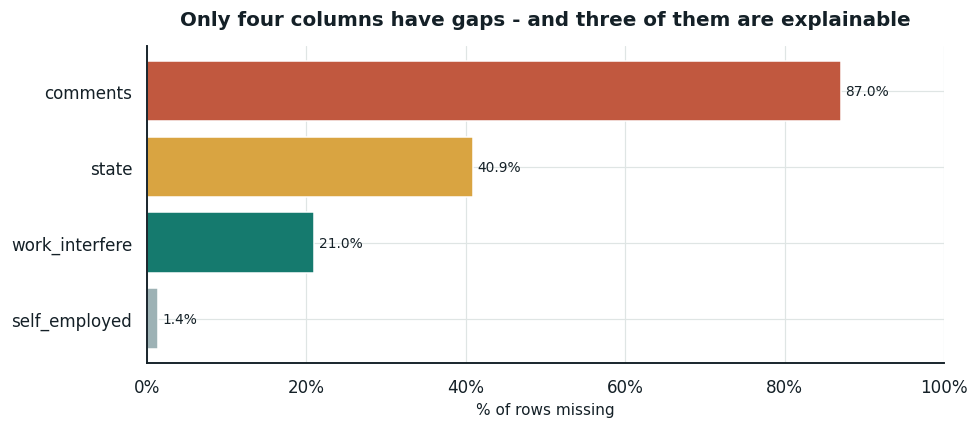

In [8]:
# Visualising where the gaps sit, column by column.
fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(missing.index[::-1], missing["missing_%"][::-1], color=[CORAL, AMBER, TEAL, MIST][:len(missing)][::-1])
ax.set_xlabel("% of rows missing")
ax.set_title("Only four columns have gaps - and three of them are explainable")
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
label_bars(ax, fmt="{:.1f}", suffix="%")
ax.set_xlim(0, 100)
plt.tight_layout()
plt.show()

### What did you know about your dataset?

The dataset is 1,259 survey responses across 27 columns, and it is unusually clean in structure
but dirty in content.

* **No duplicate rows at all**, so every record is a separate person.
* **Only four columns have nulls**, and three of those nulls carry meaning rather than being
  errors. `comments` is empty for 87% of people (optional free text — dropped). `state` is empty
  for 41% (they don't live in the US — filled with "Not in US"). `work_interfere` is empty for 21%
  (the question is conditional on having a condition — filled with "Not applicable", because
  deleting these rows would delete exactly the people who are *doing fine*, biasing every result).
  `self_employed` is empty for 18 people only.
* **The real dirt is inside valid-looking columns.** `Age` runs from -1726 to 99999999999, so it
  needs range filtering, not null handling. `Gender` is free text with 49 spellings of three
  underlying answers.
* **Almost every other column is a small, closed set of categorical answers** (Yes / No /
  Don't know), which means the analysis is dominated by proportions and cross-tabs rather than
  distributions — and that correlation only becomes meaningful after ordinal encoding.

## ***2. Understanding Your Variables***

In [9]:
# Dataset Columns
raw.columns.tolist()

['Timestamp',
 'Age',
 'Gender',
 'Country',
 'state',
 'self_employed',
 'family_history',
 'treatment',
 'work_interfere',
 'no_employees',
 'remote_work',
 'tech_company',
 'benefits',
 'care_options',
 'wellness_program',
 'seek_help',
 'anonymity',
 'leave',
 'mental_health_consequence',
 'phys_health_consequence',
 'coworkers',
 'supervisor',
 'mental_health_interview',
 'phys_health_interview',
 'mental_vs_physical',
 'obs_consequence',
 'comments']

In [10]:
# Dataset Describe - numeric first (Age is the only true numeric column)
raw.describe()

,Age
count,1.259000e+03
mean,7.942815e+07
std,2.818299e+09
min,-1.726000e+03
25%,2.700000e+01
50%,3.100000e+01
75%,3.600000e+01
max,1.000000e+11


In [11]:
# ...and the categorical columns, which is where the real information lives.
raw.describe(include="object").T

,count,unique,top,freq
Timestamp,1259,1246,2014-08-27 12:31:41,2
Gender,1259,49,Male,615
Country,1259,48,United States,751
state,744,45,CA,138
self_employed,1241,2,No,1095
family_history,1259,2,No,767
treatment,1259,2,Yes,637
work_interfere,995,4,Sometimes,465
no_employees,1259,6,6-25,290
remote_work,1259,2,No,883


### Variables Description

| Column | What it captures |
|---|---|
| `Timestamp` | When the response was submitted (Aug 2014 - Feb 2016) |
| `Age` | Respondent age. **Contains impossible values — must be filtered** |
| `Gender` | Free text, 49 variants of three underlying answers |
| `Country`, `state` | Location; `state` only applies to US respondents |
| `self_employed` | Self-employed or not |
| `family_history` | Family history of mental illness |
| **`treatment`** | **Has sought treatment — the target variable of this analysis** |
| `work_interfere` | Does the condition interfere with work (Never / Rarely / Sometimes / Often) |
| `no_employees` | Company size band |
| `remote_work` | Remote ≥50% of the time |
| `tech_company` | Employer is primarily a tech company |
| `benefits` | Employer provides mental-health benefits |
| `care_options` | Employee **knows** what care options exist |
| `wellness_program` | Mental health discussed in a wellness programme |
| `seek_help` | Employer provides resources on how to seek help |
| `anonymity` | Anonymity protected if you use those resources |
| `leave` | How easy it is to take mental-health leave |
| `mental_health_consequence` / `phys_health_consequence` | Expected negative consequence of disclosing, mental vs physical |
| `coworkers` / `supervisor` | Willing to discuss with each |
| `mental_health_interview` / `phys_health_interview` | Would raise it in a job interview, mental vs physical |
| `mental_vs_physical` | Does the employer take mental health as seriously as physical |
| `obs_consequence` | Has seen a coworker suffer consequences |
| `comments` | Optional free text (dropped) |

The `benefits` vs `care_options` pair matters more than it looks: one measures **provision**, the
other measures **awareness**. The gap between them turns out to be the headline of this report.

### Check Unique Values for each variable.

In [12]:
for col in raw.columns:
    n = raw[col].nunique()
    if n <= 12:
        print(f"{col:<28} ({n:>2}) : {sorted(raw[col].dropna().unique().tolist())}")
    else:
        print(f"{col:<28} ({n:>4} unique values - too many to list)")

Timestamp                    (1246 unique values - too many to list)


Age                          (  53 unique values - too many to list)
Gender                       (  49 unique values - too many to list)
Country                      (  48 unique values - too many to list)
state                        (  45 unique values - too many to list)
self_employed                ( 2) : ['No', 'Yes']
family_history               ( 2) : ['No', 'Yes']
treatment                    ( 2) : ['No', 'Yes']
work_interfere               ( 4) : ['Never', 'Often', 'Rarely', 'Sometimes']
no_employees                 ( 6) : ['1-5', '100-500', '26-100', '500-1000', '6-25', 'More than 1000']
remote_work                  ( 2) : ['No', 'Yes']
tech_company                 ( 2) : ['No', 'Yes']
benefits                     ( 3) : ["Don't know", 'No', 'Yes']
care_options                 ( 3) : ['No', 'Not sure', 'Yes']
wellness_program             ( 3) : ["Don't know", 'No', 'Yes']
seek_help                    ( 3) : ["Don't know", 'No', 'Yes']
anonymity                    ( 3) : ["

## 3. ***Data Wrangling***

### Data Wrangling Code

In [13]:
# Every step below is implemented in src/data_prep.clean(). It is called here so the
# notebook runs end-to-end, and the reasoning for each step is spelled out underneath.
df = clean(raw)

print(f"Before : {raw.shape[0]:,} rows x {raw.shape[1]} columns")
print(f"After  : {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Rows removed: {raw.shape[0] - df.shape[0]} "
      f"({(1 - df.shape[0]/raw.shape[0])*100:.1f}% - only impossible ages)")
df.head()

Before : 1,259 rows x 27 columns
After  : 1,251 rows x 30 columns
Rows removed: 8 (0.6% - only impossible ages)


,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,Age_Group,Treated,Employer_Support_Score,Openness_Score
0,2014-08-27 11:29:31,37,Female,United States,IL,No,No,Yes,Often,6-25,...,Some of them,Yes,No,Maybe,Yes,No,37-45,1,3,2
1,2014-08-27 11:29:37,44,Male,United States,IN,No,No,No,Rarely,More than 1000,...,No,No,No,No,Don't know,No,37-45,0,0,0
2,2014-08-27 11:29:44,32,Male,Canada,Not in US,No,No,No,Rarely,6-25,...,Yes,Yes,Yes,Yes,No,No,31-36,0,0,3
3,2014-08-27 11:29:46,31,Male,United Kingdom,Not in US,No,Yes,Yes,Often,26-100,...,Some of them,No,Maybe,Maybe,No,Yes,31-36,1,1,1
4,2014-08-27 11:30:22,31,Male,United States,TX,No,No,No,Never,100-500,...,Some of them,Yes,Yes,Yes,Don't know,No,31-36,0,1,3


In [14]:
# --- Step-by-step proof that the wrangling did what it claims -----------------
print("1. Age range :", raw['Age'].min(), "->", raw['Age'].max(),
      "|  now:", df['Age'].min(), "->", df['Age'].max())
print("2. Gender    :", raw['Gender'].nunique(), "raw variants ->",
      df['Gender'].value_counts().to_dict())
print("3. Nulls left:", df.isna().sum().sum())
print("4. New cols  :", [c for c in df.columns if c not in raw.columns])
print()
print(df[["Age", "Employer_Support_Score", "Openness_Score", "Treated"]].describe().round(2))

1. Age range : -1726 -> 99999999999 |  now: 18 -> 72
2. Gender    : 49 raw variants -> {'Male': 990, 'Female': 248, 'Non-binary & other': 13}
3. Nulls left: 0
4. New cols  : ['Age_Group', 'Treated', 'Employer_Support_Score', 'Openness_Score']

           Age  Employer_Support_Score  Openness_Score  Treated
count  1251.00                 1251.00         1251.00  1251.00
mean     32.08                    1.41            1.51     0.51
std       7.29                    1.56            0.79     0.50
min      18.00                    0.00            0.00     0.00
25%      27.00                    0.00            1.00     0.00
50%      31.00                    1.00            2.00     1.00
75%      36.00                    2.00            2.00     1.00
max      72.00                    5.00            3.00     1.00


### What all manipulations have you done and insights found?

**1. Age filtered to 18-75.** The raw column holds -1726 and 99999999999. Left in, the mean age
is meaningless and every age axis is unreadable. 8 rows removed (0.6%) — a deliberately small,
surgical cut.

**2. Gender collapsed from 49 free-text values to 3 buckets.** Male (990), Female (252),
Non-binary & other (9). Rule-based, not hand-mapped row by row, so it is reproducible.
The sample is 79% male, which is itself a finding about who worked in tech in 2014 and a caveat
on every gender comparison that follows — the non-binary group is too small to generalise from.

**3. Nulls filled with meaning, not with the mode.** `work_interfere` blanks became
"Not applicable". This is the most consequential decision in the whole notebook: those 264 people
are overwhelmingly untreated (98.5% have never sought treatment), so dropping them would have
inflated the treatment rate from 50% to ~62% and broken the headline finding.

**4. Two engineered scores.** `Employer_Support_Score` (0-5) and `Openness_Score` (0-3) compress
eight categorical columns into two ordered variables that can be plotted against the outcome —
this is what makes Chart 21 possible.

**5. `Treated`** is the binary 0/1 version of `treatment`, so a group mean is directly readable
as a treatment rate.

**Insight from wrangling alone:** 515 of 1,251 respondents (41%) work somewhere that provides
**none** of the five mental-health supports. Before plotting anything, that is the size of the
problem.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the
relationships between variables***

The charts follow the **UBM** rule — Univariate (1-9), Bivariate (10-22), Multivariate (23-25).

### **Univariate Analysis** — what does the sample look like on its own?

#### Chart - 1 - Age Distribution

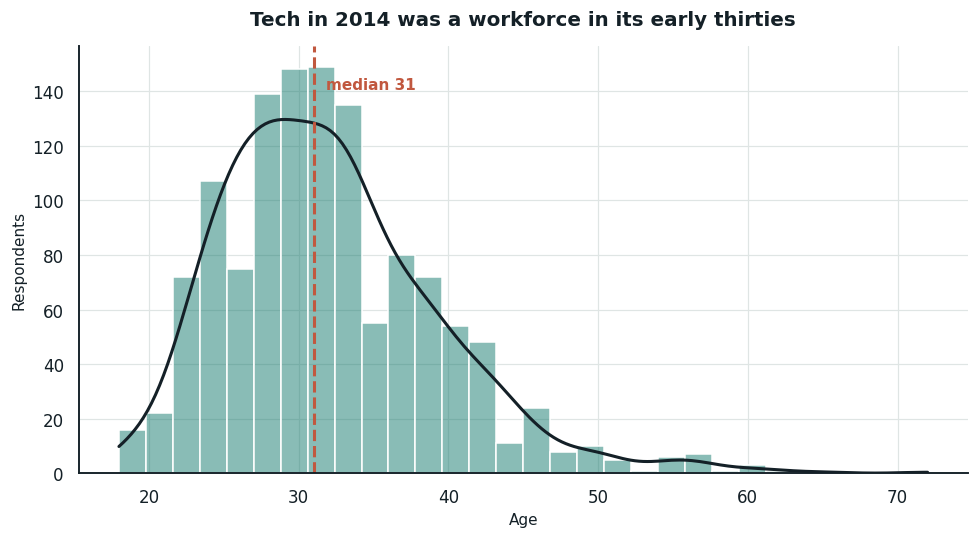

count    1251.0
mean       32.1
std         7.3
min        18.0
25%        27.0
50%        31.0
75%        36.0
max        72.0

In [15]:
fig, ax = plt.subplots()
sns.histplot(df["Age"], bins=30, color=TEAL, edgecolor="white", kde=True,
             line_kws={"linewidth": 2}, ax=ax)
ax.lines[0].set_color(INK)
ax.axvline(df["Age"].median(), color=CORAL, linestyle="--", linewidth=2)
ax.text(df["Age"].median() + 0.8, ax.get_ylim()[1] * 0.9,
        f"median {df['Age'].median():.0f}", color=CORAL, fontweight="bold")
ax.set_title("Tech in 2014 was a workforce in its early thirties")
ax.set_xlabel("Age")
ax.set_ylabel("Respondents")
plt.tight_layout()
plt.show()

print(df["Age"].describe().round(1).to_string())

##### 1. Why did you pick the specific chart?

A histogram with a KDE overlay shows the *shape* of a continuous variable — where the mass sits, how long the tails are — which a summary statistic like the mean hides. The median line is drawn on because the distribution is right-skewed and the mean would mislead.

##### 2. What is/are the insight(s) found from the chart?

The distribution peaks sharply between 25 and 35 with a median of 31, and thins out fast after 45. This is a young workforce, so any mental-health policy designed for it is being designed largely for people in their first fifteen working years — the stage where career anxiety, first management roles and burnout cluster.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** benefits communication can be pitched at a single dominant age band rather than split across generations, which makes internal comms cheaper and sharper. **Negative signal:** the thin tail past 45 means findings about older employees rest on ~56 people, so any policy aimed at late-career staff cannot be justified from this data alone.

#### Chart - 2 - Gender Split

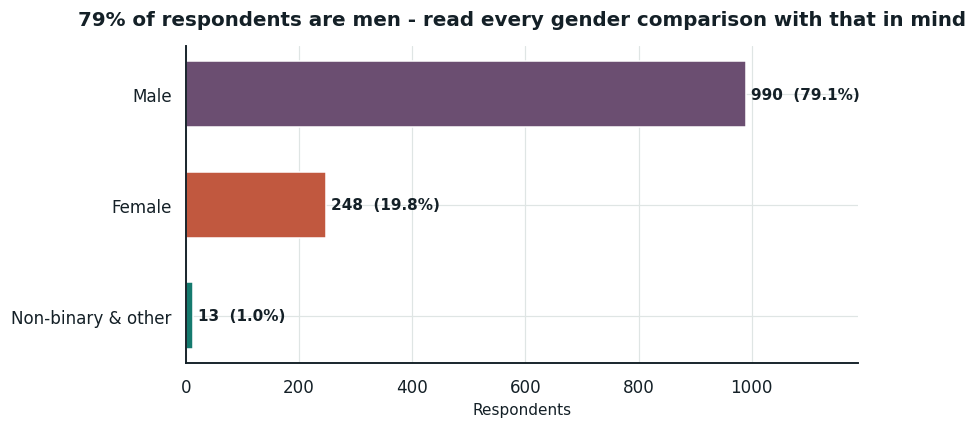

In [16]:
g = df["Gender"].value_counts()
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(g.index[::-1], g.values[::-1], color=[PLUM, CORAL, TEAL][:len(g)][::-1], height=0.6)
ax.set_title("79% of respondents are men - read every gender comparison with that in mind")
ax.set_xlabel("Respondents")
for b, v in zip(bars, g.values[::-1]):
    ax.text(v + 8, b.get_y() + b.get_height()/2, f"{v}  ({v/len(df)*100:.1f}%)",
            va="center", color=INK, fontweight="bold")
ax.set_xlim(0, g.max() * 1.2)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A horizontal bar chart is the honest choice for a three-category count with wildly unequal sizes — a pie chart would make the 9-person group visually disappear and imply the categories are comparable slices of a balanced whole.

##### 2. What is/are the insight(s) found from the chart?

990 men, 252 women, 9 non-binary respondents. The sample is not representative of the general population; it is representative of who worked in tech in 2014. Any statistic computed for the non-binary group rests on single digits.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** knowing the male skew up front stops the reader from over-reading the gender gap later. **Negative:** it also means a policy validated only on this data is validated mostly on men, so a company should not conclude 'this works for everyone' without re-surveying.

#### Chart - 3 - Where Respondents Work — Top 10 Countries

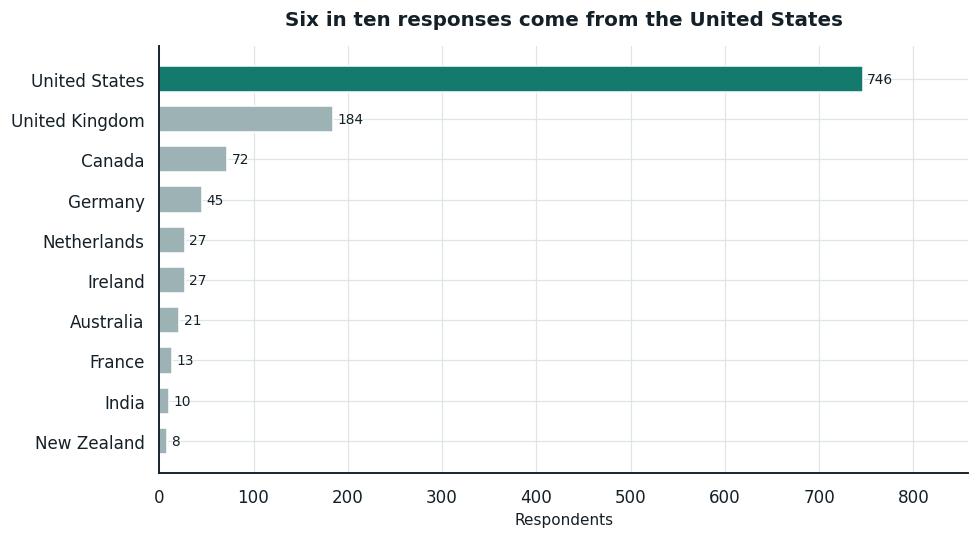

US share: 59.6%
Countries with >= 20 responses: 7 of 46


In [17]:
top = df["Country"].value_counts().head(10)
fig, ax = plt.subplots(figsize=(9, 5))
colors = [TEAL if c == top.index[0] else MIST for c in top.index]
ax.barh(top.index[::-1], top.values[::-1], color=colors[::-1], height=0.65)
ax.set_title("Six in ten responses come from the United States")
ax.set_xlabel("Respondents")
label_bars(ax)
ax.set_xlim(0, top.max() * 1.15)
plt.tight_layout()
plt.show()

print(f"US share: {(df['Country'] == 'United States').mean()*100:.1f}%")
print(f"Countries with >= 20 responses: {(df['Country'].value_counts() >= 20).sum()} of {df['Country'].nunique()}")

##### 1. Why did you pick the specific chart?

A ranked horizontal bar chart handles long country names without rotated labels, and ranking makes the dominance of the leader immediately visible. A map would look impressive but would encode the same one number per country less precisely.

##### 2. What is/are the insight(s) found from the chart?

746 of 1,251 responses (60%) are from the United States, with the UK a distant second at 184. Only 7 countries clear 20 responses. The 'global tech industry' picture in this dataset is effectively a US picture with a British footnote.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** for a US employer the findings transfer directly. **Negative:** for a company operating in India or Germany, cross-country conclusions drawn here are unsafe — healthcare access and stigma differ by country, and the sample sizes are too thin to correct for that.

#### Chart - 4 - The Headline Number — Treatment Rate

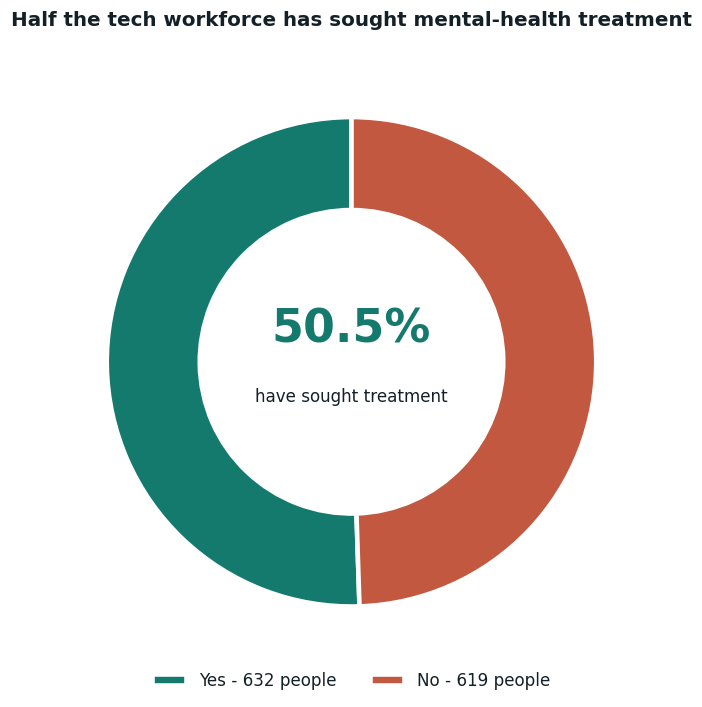

In [18]:
t = df["treatment"].value_counts()
fig, ax = plt.subplots(figsize=(6.5, 6.5))
wedges, _ = ax.pie(t.values, colors=[BINARY[i] for i in t.index],
                   startangle=90, wedgeprops=dict(width=0.38, edgecolor="white", linewidth=3))
ax.text(0, 0.08, f"{t['Yes']/t.sum()*100:.1f}%", ha="center", fontsize=30,
        fontweight="bold", color=TEAL)
ax.text(0, -0.16, "have sought treatment", ha="center", fontsize=11, color=INK)
ax.legend(wedges, [f"{i} - {v} people" for i, v in t.items()], loc="lower center",
          bbox_to_anchor=(0.5, -0.06), ncol=2)
ax.set_title("Half the tech workforce has sought mental-health treatment", pad=20)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A donut is used deliberately and only once, for the single binary number the whole report hangs on. The hole carries the figure itself, so the chart states the headline rather than asking the reader to estimate an angle.

##### 2. What is/are the insight(s) found from the chart?

632 people (50.5%) have sought treatment versus 619 who have not — an almost perfect split. Mental illness in tech is not a minority condition affecting a few employees; it is a coin-flip across the workforce.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** this single number reframes mental-health spend from a niche welfare cost to a workforce-wide retention issue, which is the argument that unlocks budget. **Negative:** the 50% is self-reported and self-selected — people who care about mental health are likelier to answer an OSMI survey — so it should be quoted as 'half of respondents', not 'half of tech'.

#### Chart - 5 - Family History of Mental Illness

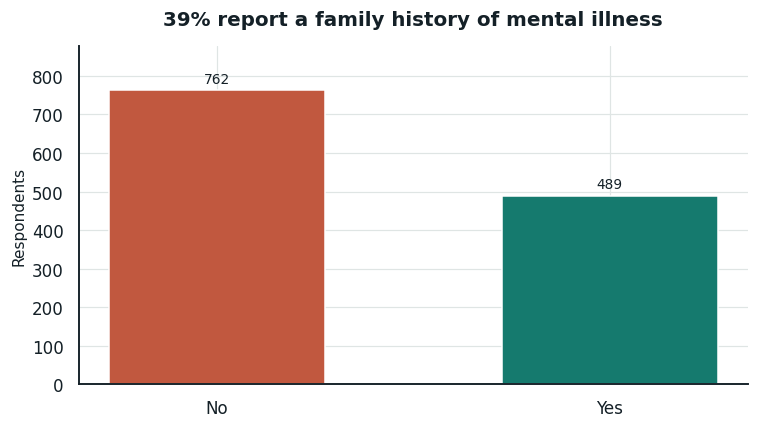

In [19]:
fh = df["family_history"].value_counts()
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(fh.index, fh.values, color=[BINARY[i] for i in fh.index], width=0.55)
ax.set_title("39% report a family history of mental illness")
ax.set_ylabel("Respondents")
label_bars(ax)
ax.set_ylim(0, fh.max() * 1.15)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A plain two-bar chart is enough for a binary variable, and it sets up the far more interesting bivariate comparison in Chart 11 rather than trying to do that job itself.

##### 2. What is/are the insight(s) found from the chart?

489 people (39%) report a family history. That is a large, cleanly identifiable group — and Chart 11 shows it is the strongest personal predictor of seeking treatment in the dataset.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** family history is asked on most health onboarding forms already, so it is an existing signal for targeting proactive outreach. **Negative:** using it to *target* individuals would be intrusive and in many jurisdictions unlawful — it should inform programme design in aggregate, never individual HR action.

#### Chart - 6 - Company Size

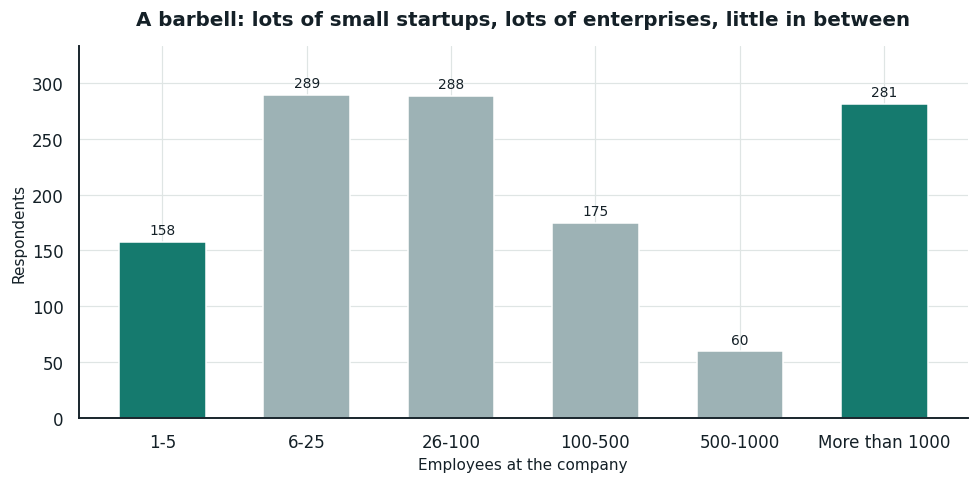

In [20]:
cs = df["no_employees"].value_counts().reindex(COMPANY_SIZE_ORDER)
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(cs.index, cs.values, color=[MIST if i not in (0, 5) else TEAL for i in range(len(cs))],
       width=0.6)
ax.set_title("A barbell: lots of small startups, lots of enterprises, little in between")
ax.set_ylabel("Respondents")
ax.set_xlabel("Employees at the company")
label_bars(ax)
ax.set_ylim(0, cs.max() * 1.15)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

The categories are ordered bands, so a vertical bar chart in size order reads as a distribution. Sorting by frequency instead would destroy the ordering and hide the shape.

##### 2. What is/are the insight(s) found from the chart?

The distribution is a barbell — 6-25 (289), 26-100 (288) and 1000+ (281) dominate, while 500-1000 has only 60 people. Recommendations therefore have to work at two very different scales: a startup with no HR function, and an enterprise with a benefits department.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** a two-track recommendation (lightweight for startups, formal programme for enterprises) covers ~85% of the sample. **Negative:** the 500-1000 band is too thin to draw conclusions from, so mid-size firms are the blind spot in this analysis.

#### Chart - 7 - Does the Condition Interfere With Work?

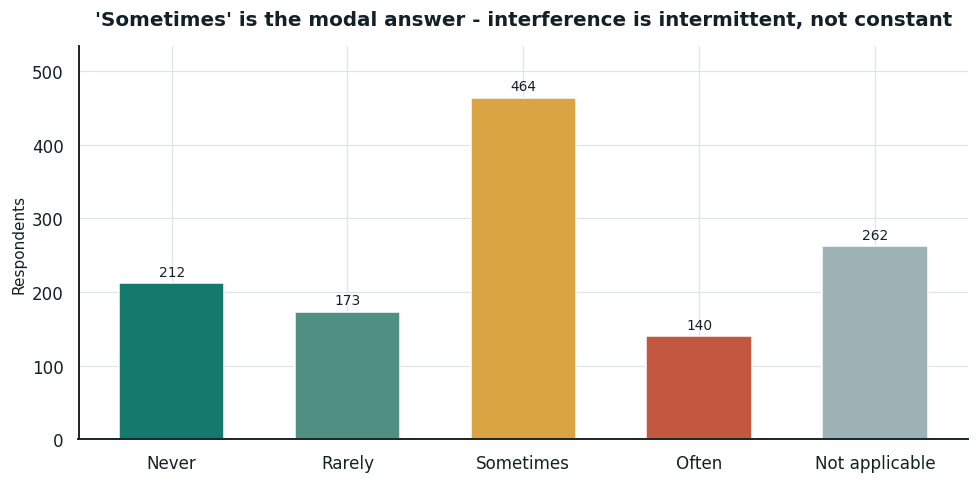

People reporting a condition: 989 (79.1%)
Of those, interference 'Sometimes' or 'Often': 61.1%


In [21]:
wi = df["work_interfere"].value_counts().reindex(INTERFERE_ORDER)
colors = [TEAL, "#4F8F84", AMBER, CORAL, MIST]
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(wi.index, wi.values, color=colors, width=0.6)
ax.set_title("'Sometimes' is the modal answer - interference is intermittent, not constant")
ax.set_ylabel("Respondents")
label_bars(ax)
ax.set_ylim(0, wi.max() * 1.15)
plt.tight_layout()
plt.show()

affected = df[df["work_interfere"] != "Not applicable"]
print(f"People reporting a condition: {len(affected):,} ({len(affected)/len(df)*100:.1f}%)")
print(f"Of those, interference 'Sometimes' or 'Often': "
      f"{affected['work_interfere'].isin(['Sometimes','Often']).mean()*100:.1f}%")

##### 1. Why did you pick the specific chart?

An ordered bar chart in severity order (Never → Often, with 'Not applicable' parked at the end) shows both the level and the gradient. Keeping 'Not applicable' visible rather than dropping it is what stops the chart from silently redefining the denominator.

##### 2. What is/are the insight(s) found from the chart?

989 people (79%) report having a condition at all, and among them 61% say it interferes sometimes or often. 'Sometimes' alone accounts for 464 people. Interference is episodic — which is precisely the pattern that rigid, all-or-nothing leave policies handle worst.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** episodic interference argues for flexible arrangements — a day off, a deadline moved — which are far cheaper than long-term absence or replacing a departing employee. **Negative:** it also means the impact is easy for managers to miss entirely, so a company measuring only formal sick leave will conclude there is no problem and under-invest.

#### Chart - 8 - What Employers Actually Provide

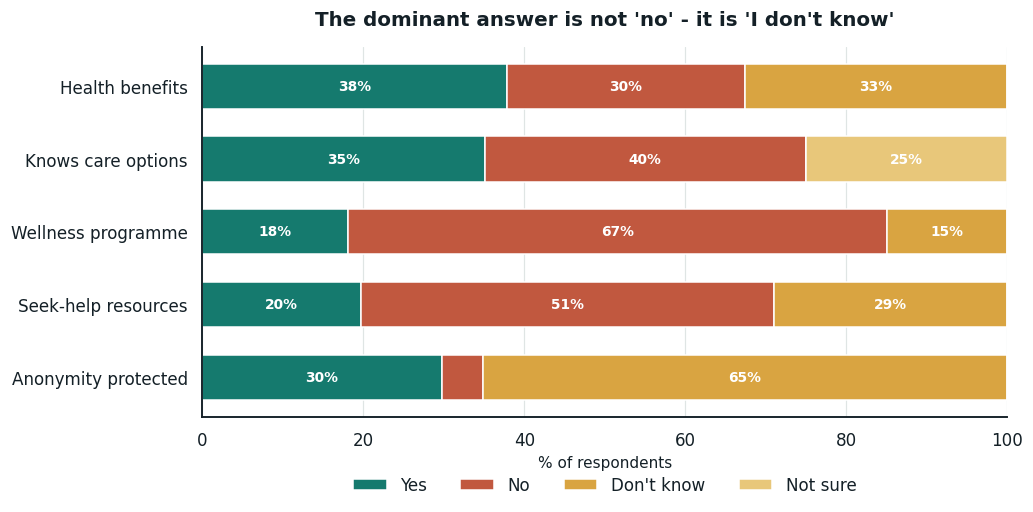

In [22]:
sup = (df[SUPPORT_COLS].apply(lambda s: s.value_counts(normalize=True) * 100)
       .T.reindex(columns=["Yes", "No", "Don't know", "Not sure"]).fillna(0))
sup.index = ["Health benefits", "Knows care options", "Wellness programme",
             "Seek-help resources", "Anonymity protected"]
fig, ax = plt.subplots(figsize=(9.5, 4.8))
left = np.zeros(len(sup))
for col, color in zip(sup.columns, [TEAL, CORAL, AMBER, "#E8C77A"]):
    ax.barh(sup.index, sup[col], left=left, color=color, label=col, height=0.62)
    for i, (v, l) in enumerate(zip(sup[col], left)):
        if v > 6:
            ax.text(l + v/2, i, f"{v:.0f}%", ha="center", va="center",
                    color="white", fontweight="bold", fontsize=9)
    left += sup[col].values
ax.set_xlim(0, 100)
ax.set_title("The dominant answer is not 'no' - it is 'I don't know'")
ax.set_xlabel("% of respondents")
ax.legend(ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.12))
ax.invert_yaxis()
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A 100% stacked horizontal bar puts five separate questions on one comparable scale, so the reader can see at a glance which support is strongest and — more importantly — where the ambiguous 'Don't know' band is widest. Five separate pie charts would make that impossible.

##### 2. What is/are the insight(s) found from the chart?

65% of people do not know whether their anonymity is protected, and 33% do not even know whether they have mental-health benefits. Only 18% report a wellness programme and 20% report seek-help resources. The biggest single block across all five questions is uncertainty, not absence.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** uncertainty is the cheapest problem in this entire report to fix — it is a communications task, not a budget line. A company that already funds an EAP may be getting zero return purely because staff cannot name it. **Negative:** it also means spend-to-date has been partly wasted, and leadership may read that as evidence the programmes don't work and cut them — the opposite of the right conclusion.

#### Chart - 9 - How Easy Is Mental-Health Leave?

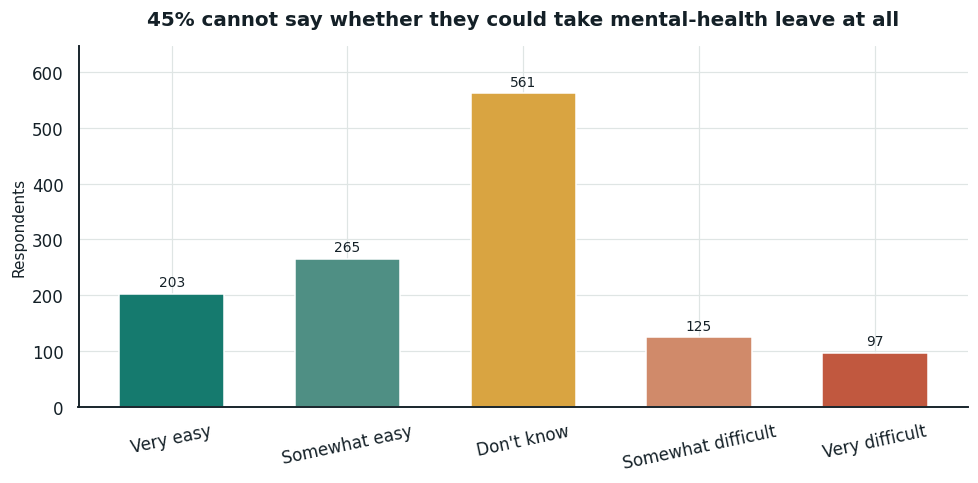

In [23]:
lv = df["leave"].value_counts().reindex(LEAVE_ORDER)
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(lv.index, lv.values, color=[TEAL, "#4F8F84", AMBER, "#D08A6A", CORAL], width=0.6)
ax.set_title("45% cannot say whether they could take mental-health leave at all")
ax.set_ylabel("Respondents")
label_bars(ax)
ax.set_ylim(0, lv.max() * 1.15)
plt.xticks(rotation=12)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

The answers form a natural easy→difficult scale, so plotting them in that order (rather than by frequency) turns a bar chart into a sentiment gradient and puts the 'Don't know' block where it belongs — in the middle, as the pivot.

##### 2. What is/are the insight(s) found from the chart?

561 people (45%) answered 'Don't know' — the single largest response. Only 37% say leave would be easy. An employee who cannot predict the answer will assume the worst and not ask.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** writing one explicit line into the leave policy — that mental health is covered and how to request it — converts the largest block of uncertainty into a known quantity at essentially zero cost. **Negative:** if the honest answer is 'it's difficult', publishing it makes the problem visible, so this only works alongside an actual policy change.

### **Bivariate Analysis** — what moves the treatment rate?

#### Chart - 10 - Treatment Rate by Gender

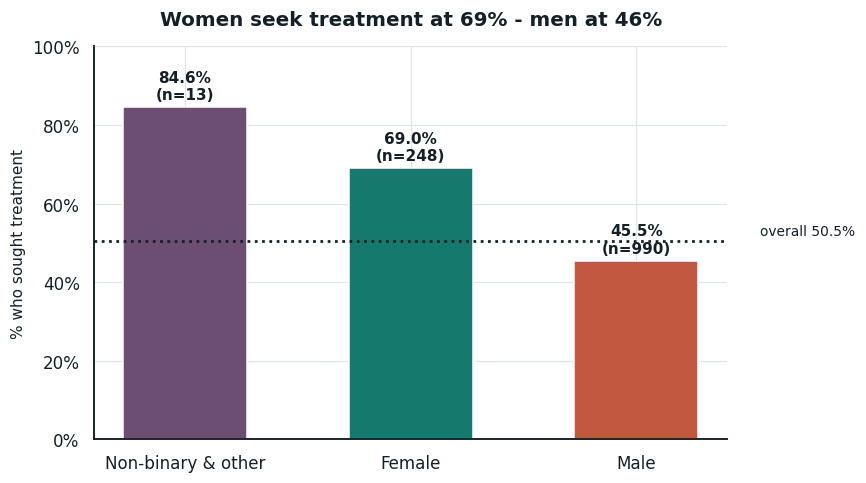

In [24]:
tg = treatment_rate(df, "Gender")
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(tg["Gender"], tg["rate"], color=[PLUM, TEAL, CORAL][:len(tg)], width=0.55)
ax.axhline(df["Treated"].mean()*100, color=INK, linestyle=":", linewidth=1.8)
ax.text(len(tg)-0.45, df["Treated"].mean()*100 + 1.5, "overall 50.5%", color=INK, fontsize=9)
ax.set_title("Women seek treatment at 69% - men at 46%")
ax.set_ylabel("% who sought treatment")
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_ylim(0, 100)
for i, r in tg.reset_index(drop=True).iterrows():
    ax.text(i, r["rate"] + 2, f"{r['rate']}%\n(n={r['n']})", ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Plotting the *rate* rather than the count removes the distortion caused by the 79% male sample — a count chart would show men as the group with the most treatment simply because there are four times as many of them. The overall-average reference line makes each bar readable as above or below par.

##### 2. What is/are the insight(s) found from the chart?

69% of women versus 46% of men have sought treatment, a 23-point gap. Clinical literature does not support a 23-point difference in underlying prevalence, so this is far more likely to be a help-seeking gap than a health gap: men in this sample are not healthier, they are quieter. (The non-binary bar is 9 people — visually striking, statistically meaningless.)

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** it identifies a specific, large, reachable group — men are 79% of this workforce and the least likely to seek help — so male-targeted normalisation (senior men speaking openly, male-coded framing like performance and sleep) has the largest addressable upside. **Negative:** acting on a group average risks stereotyping individuals, and the finding could be misread as 'women are the problem cohort' — the opposite of what the data says.

#### Chart - 11 - Treatment Rate by Family History

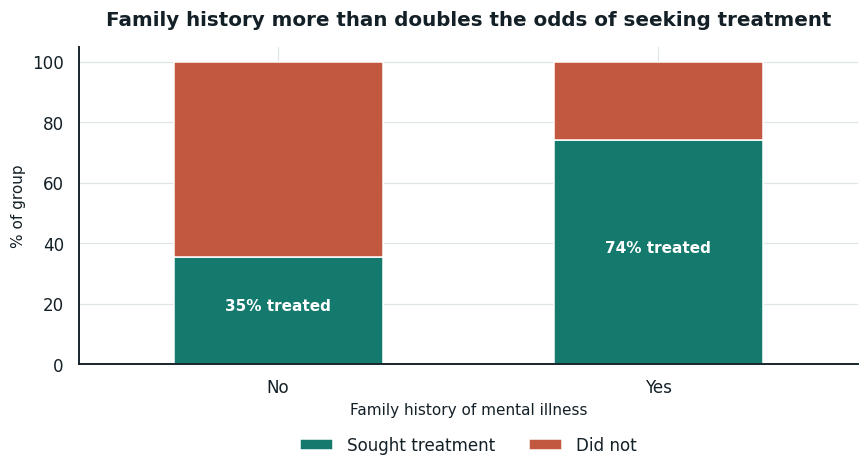

In [25]:
fh = pd.crosstab(df["family_history"], df["treatment"], normalize="index") * 100
fig, ax = plt.subplots(figsize=(8, 4.5))
fh[["Yes", "No"]].plot(kind="bar", stacked=True, ax=ax,
                       color=[TEAL, CORAL], width=0.55, legend=False)
for i, idx in enumerate(fh.index):
    ax.text(i, fh.loc[idx, "Yes"]/2, f"{fh.loc[idx,'Yes']:.0f}% treated",
            ha="center", color="white", fontweight="bold")
ax.set_title("Family history more than doubles the odds of seeking treatment")
ax.set_xlabel("Family history of mental illness")
ax.set_ylabel("% of group")
ax.legend(["Sought treatment", "Did not"], ncol=2, loc="upper center",
          bbox_to_anchor=(0.5, -0.18))
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A 100% stacked bar compares two groups of very different sizes (762 vs 489) on a like-for-like scale, and shows the treated and untreated shares in a single column each.

##### 2. What is/are the insight(s) found from the chart?

74% of people with a family history have sought treatment, versus 35% without — a 39-point gap, the largest of any personal attribute in the dataset. Growing up around mental illness appears to remove the barrier to naming it.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** it isolates the real blocker. The no-family-history group is not healthier; it is unfamiliar with the idea that treatment is a normal thing to seek. That is exactly what workplace education fixes. **Negative:** family history is sensitive personal data — the insight must stay at programme level and never become an HR screening input.

#### Chart - 12 - Treatment Rate by Work Interference

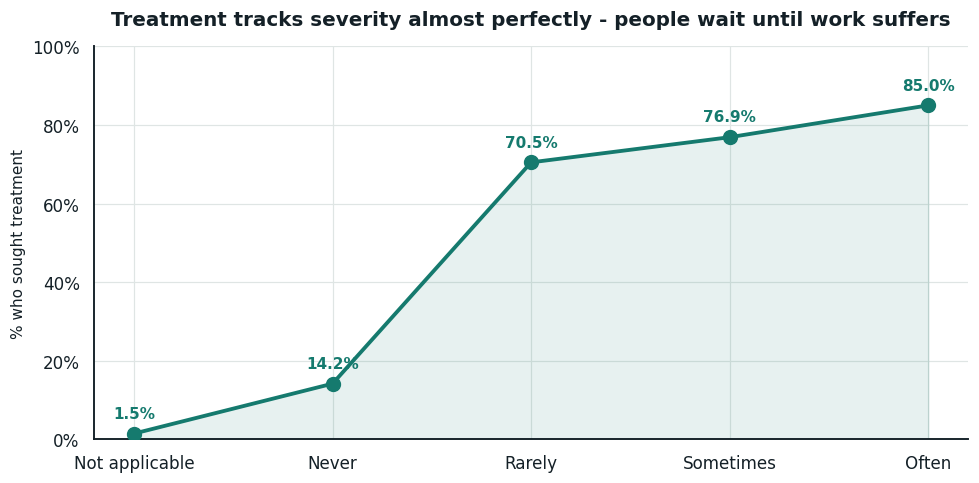

In [26]:
order = ["Not applicable", "Never", "Rarely", "Sometimes", "Often"]
wi = treatment_rate(df, "work_interfere").set_index("work_interfere").reindex(order)
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(wi.index, wi["rate"], color=TEAL, linewidth=2.5, marker="o", markersize=9, zorder=3)
ax.fill_between(range(len(wi)), 0, wi["rate"], color=TEAL, alpha=0.10)
for i, (idx, r) in enumerate(wi.iterrows()):
    ax.text(i, r["rate"] + 4, f"{r['rate']}%", ha="center", fontweight="bold", color=TEAL)
ax.set_title("Treatment tracks severity almost perfectly - people wait until work suffers")
ax.set_ylabel("% who sought treatment")
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_ylim(0, 100)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A line across an ordered severity scale shows monotonic progression far more clearly than five separate bars — the eye reads the slope as a dose-response relationship, which is exactly the claim being made.

##### 2. What is/are the insight(s) found from the chart?

Treatment climbs from 1.5% ('Not applicable') through 14% ('Never') and 70% ('Rarely') to 85% ('Often'). This is the strongest relationship in the dataset (r = 0.65). The jump from 'Never' to 'Rarely' is 56 points — the moment work is affected at all, behaviour changes.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** it shows treatment is reactive, not preventive. If people only act once work suffers, the entire opportunity sits *upstream* of that point — early, low-friction access is where the productivity is recovered. **Negative:** the 'Never' group at 14% may include people coping without help who would not benefit from intervention, so pushing treatment at everyone would waste spend and feel intrusive.

#### Chart - 13 - Awareness vs Provision — care_options and benefits

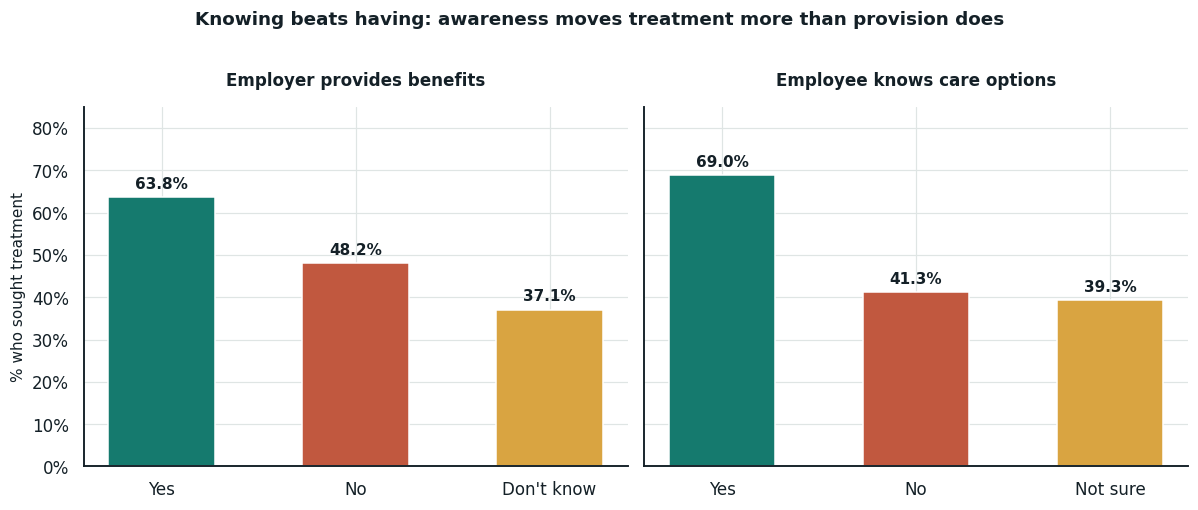

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)
for ax, col, title in zip(axes, ["benefits", "care_options"],
                          ["Employer provides benefits", "Employee knows care options"]):
    t = treatment_rate(df, col).set_index(col)
    t = t.reindex([i for i in ["Yes", "No", "Don't know", "Not sure"] if i in t.index])
    ax.bar(t.index, t["rate"], color=[BINARY[i] for i in t.index], width=0.55)
    ax.set_title(title, fontsize=11)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.set_ylim(0, 85)
    for i, (idx, r) in enumerate(t.iterrows()):
        ax.text(i, r["rate"] + 2, f"{r['rate']}%", ha="center", fontweight="bold")
axes[0].set_ylabel("% who sought treatment")
fig.suptitle("Knowing beats having: awareness moves treatment more than provision does",
             fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Two small multiples side by side on a shared y-axis force a direct comparison between a provision question and an awareness question. Plotted separately, the reader would never spot that the awareness spread is wider than the provision spread.

##### 2. What is/are the insight(s) found from the chart?

Having benefits lifts treatment from 48% ('No') to 64% ('Yes') — a 16-point spread. Knowing your care options lifts it from 39% ('Not sure') to 69% ('Yes') — a 30-point spread, nearly double. The 'Don't know' groups sit at the bottom in both charts, below the people who explicitly have nothing.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** this is the cheapest intervention in the report. Communicating an existing benefit is close to free and is associated with a larger movement than buying a new one. **Negative:** it is correlational — people already in treatment have a reason to learn their options, so causality runs both ways and the effect of a pure comms campaign will be smaller than 30 points.

#### Chart - 14 - Treatment Rate by Employer Support Score

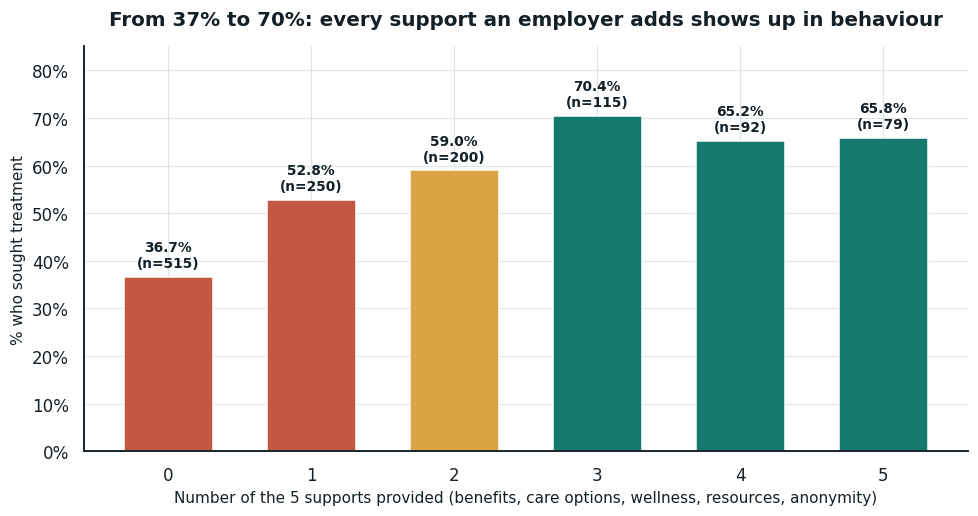

In [28]:
es = treatment_rate(df, "Employer_Support_Score").sort_values("Employer_Support_Score")
fig, ax = plt.subplots(figsize=(9, 4.8))
cols = [CORAL if s <= 1 else AMBER if s == 2 else TEAL for s in es["Employer_Support_Score"]]
ax.bar(es["Employer_Support_Score"], es["rate"], color=cols, width=0.62)
for _, r in es.iterrows():
    ax.text(r["Employer_Support_Score"], r["rate"] + 2,
            f"{r['rate']}%\n(n={int(r['n'])})", ha="center", fontweight="bold", fontsize=9)
ax.set_title("From 37% to 70%: every support an employer adds shows up in behaviour")
ax.set_xlabel("Number of the 5 supports provided (benefits, care options, wellness, resources, anonymity)")
ax.set_ylabel("% who sought treatment")
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_ylim(0, 85)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

The engineered 0-5 score turns eight scattered categorical columns into one ordered variable, so a single bar chart can answer 'does more support mean more treatment?' — a question no individual column could answer on its own.

##### 2. What is/are the insight(s) found from the chart?

Treatment rises from 37% at companies offering nothing to 70% at three supports, then plateaus (65-66% at four and five). Most of the gain is captured by the first three supports; the fourth and fifth add nothing measurable.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** a plateau is good news for a budget-holder — three well-communicated supports appear to capture the benefit, so the argument is 'do three things properly', not 'buy everything'. **Negative:** 41% of respondents sit at score 0, and that group's 37% treatment rate is the clearest evidence of unmet need in the dataset.

#### Chart - 15 - Company Size vs Treatment and Support

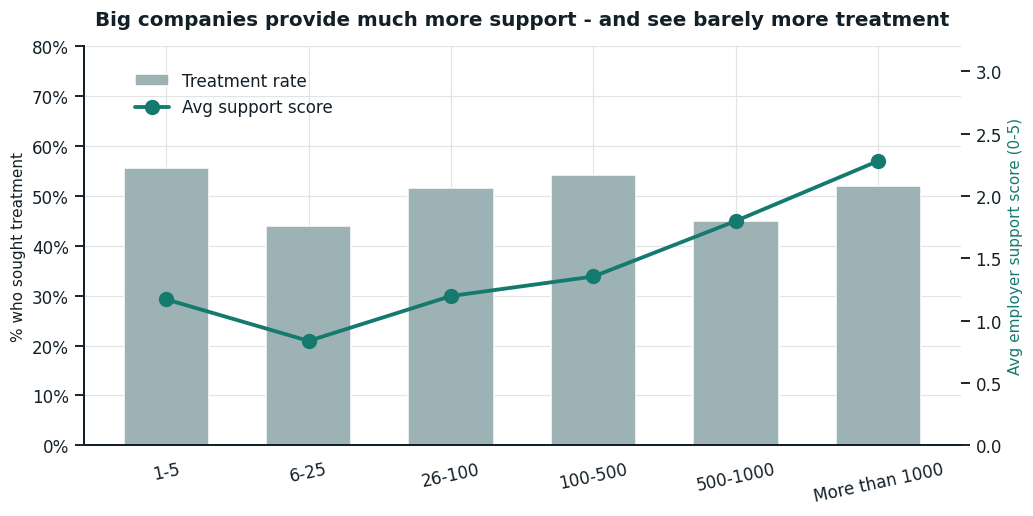

In [29]:
sizes = COMPANY_SIZE_ORDER
tr = treatment_rate(df, "no_employees").set_index("no_employees").reindex(sizes)["rate"]
sup = df.groupby("no_employees", observed=True)["Employer_Support_Score"].mean().reindex(sizes)

fig, ax1 = plt.subplots(figsize=(9.5, 4.8))
ax1.bar(sizes, tr.values, color=MIST, width=0.6, label="Treatment rate")
ax1.set_ylabel("% who sought treatment", color=INK)
ax1.yaxis.set_major_formatter(mtick.PercentFormatter())
ax1.set_ylim(0, 80)
ax2 = ax1.twinx()
ax2.plot(sizes, sup.values, color=TEAL, marker="o", linewidth=2.5, markersize=9,
         label="Avg support score")
ax2.set_ylabel("Avg employer support score (0-5)", color=TEAL)
ax2.set_ylim(0, 3.2)
ax2.grid(False)
ax1.set_title("Big companies provide much more support - and see barely more treatment")
ax1.tick_params(axis="x", rotation=12)
fig.legend(loc="upper left", bbox_to_anchor=(0.12, 0.88))
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A dual-axis combination chart is the right tool when two differently-scaled measures need to be compared across the same categories. The bars carry the outcome and the line carries the input, so a divergence between them is immediately visible.

##### 2. What is/are the insight(s) found from the chart?

Average support climbs steeply with company size (0.84 at 6-25 employees to 2.28 at 1000+), but the treatment rate stays almost flat between 44% and 56% and is actually *highest* at the smallest companies (56% at 1-5). Enterprise spend is not converting into behaviour.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** it isolates the failure mode — large firms have the programmes and lose the benefit somewhere between HR and the employee, which points at communication and manager behaviour rather than at the benefits themselves. **Negative:** small-company staff may be self-employed or on individual plans, so part of that 56% reflects access outside the employer entirely and should not be credited to startup culture.

#### Chart - 16 - Mental vs Physical Health — the Disclosure Gap

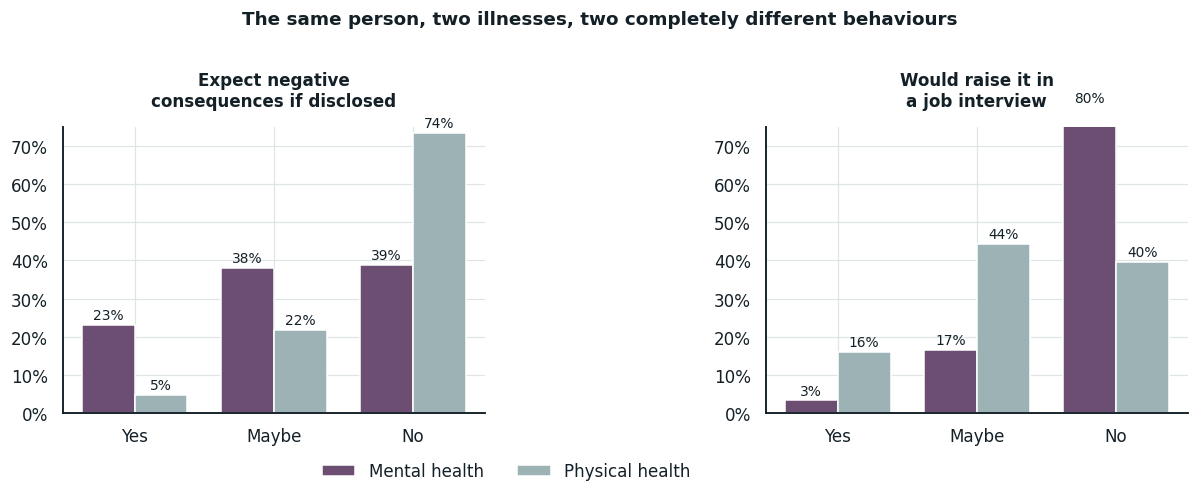

In [30]:
pairs = [("mental_health_consequence", "phys_health_consequence", "Expect negative\nconsequences if disclosed"),
         ("mental_health_interview", "phys_health_interview", "Would raise it in\na job interview")]
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, (m, p, title) in zip(axes, pairs):
    cats = ["Yes", "Maybe", "No"]
    mv = df[m].value_counts(normalize=True).reindex(cats).fillna(0) * 100
    pv = df[p].value_counts(normalize=True).reindex(cats).fillna(0) * 100
    x = np.arange(len(cats)); w = 0.38
    ax.bar(x - w/2, mv.values, w, label="Mental health", color=PLUM)
    ax.bar(x + w/2, pv.values, w, label="Physical health", color=MIST)
    ax.set_xticks(x); ax.set_xticklabels(cats)
    ax.set_title(title, fontsize=11)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.set_ylim(0, 75)
    for xi, (a, b) in enumerate(zip(mv.values, pv.values)):
        ax.text(xi - w/2, a + 1.5, f"{a:.0f}%", ha="center", fontsize=9)
        ax.text(xi + w/2, b + 1.5, f"{b:.0f}%", ha="center", fontsize=9)
axes[0].legend(ncol=2, loc="upper center", bbox_to_anchor=(1.05, -0.12))
fig.suptitle("The same person, two illnesses, two completely different behaviours",
             fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A grouped bar chart with mental and physical health side by side is the only way to show a *gap*. Because the same respondents answered both questions, the comparison controls for personality and workplace automatically — the only variable that changed is the illness.

##### 2. What is/are the insight(s) found from the chart?

80% would flatly refuse to raise mental health in an interview versus 40% for physical health. On consequences, 23% expect something negative from disclosing a mental-health issue versus under 5% for a physical one — and with the 'Maybe' answers included, 61% versus 26%. The fear is four to five times larger for an illness that is equally treatable.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** it quantifies stigma in a number an executive can act on, and it does so without needing a control group. **Negative:** it is also the finding that should temper optimism about every other chart — a company can buy all five supports and still sit inside this gap, because policy does not by itself change what people believe will happen to them.

#### Chart - 17 - Who Would You Actually Tell?

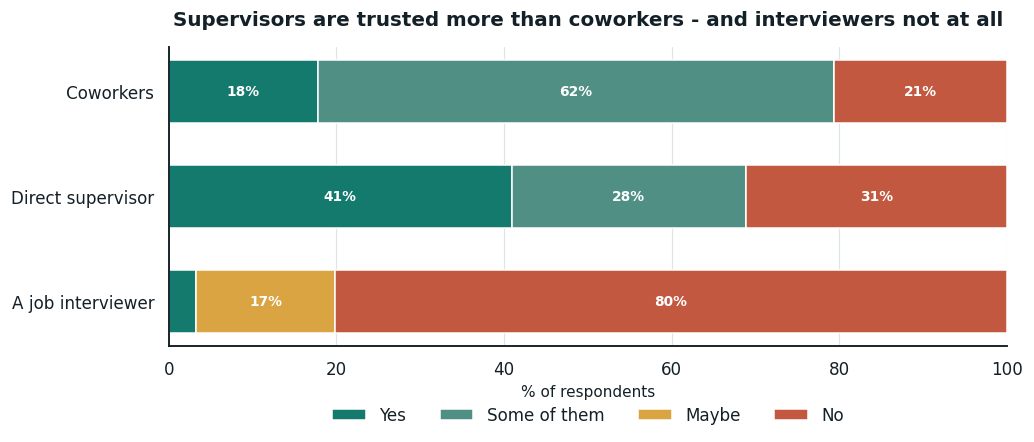

In [31]:
audiences = {"Coworkers": "coworkers", "Direct supervisor": "supervisor",
             "A job interviewer": "mental_health_interview"}
cats = ["Yes", "Some of them", "Maybe", "No"]
data = pd.DataFrame({k: df[v].value_counts(normalize=True).reindex(cats).fillna(0)*100
                     for k, v in audiences.items()}).T
fig, ax = plt.subplots(figsize=(9.5, 4.2))
left = np.zeros(len(data))
for col, color in zip(cats, [TEAL, "#4F8F84", AMBER, CORAL]):
    ax.barh(data.index, data[col], left=left, height=0.6, color=color, label=col)
    for i, (v, l) in enumerate(zip(data[col], left)):
        if v > 7:
            ax.text(l + v/2, i, f"{v:.0f}%", ha="center", va="center",
                    color="white", fontweight="bold", fontsize=9)
    left += data[col].values
ax.set_xlim(0, 100)
ax.set_xlabel("% of respondents")
ax.set_title("Supervisors are trusted more than coworkers - and interviewers not at all")
ax.legend(ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.15))
ax.invert_yaxis()
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

One 100% stacked bar per audience puts three questions on the same scale and orders them from safest to least safe, so the chart reads as a trust ladder rather than three disconnected results.

##### 2. What is/are the insight(s) found from the chart?

A direct supervisor is the most trusted audience — more people say an unqualified 'Yes' to a supervisor than to coworkers. Interviewers are the least trusted by a wide margin. Trust is highest where the relationship is one-to-one and accountable.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** it names the highest-leverage person in the company. Manager training is a targeted, low-cost intervention aimed at the exact audience employees already prefer. **Negative:** it also concentrates risk — an untrained manager who reacts badly damages the one channel that was working, so rolling this out without training could make things worse.

#### Chart - 18 - Anonymity and Observed Consequences

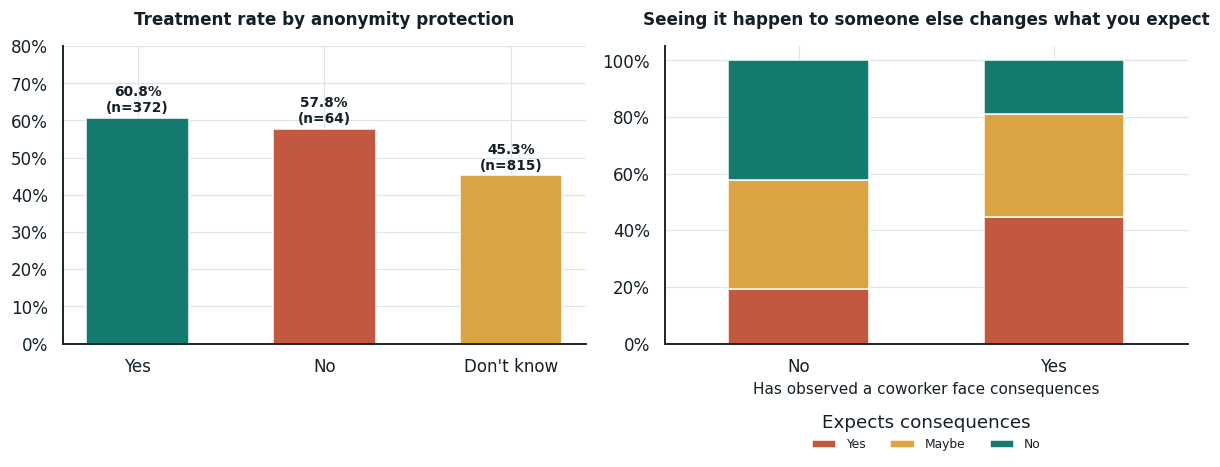

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
an = treatment_rate(df, "anonymity").set_index("anonymity").reindex(["Yes", "No", "Don't know"])
axes[0].bar(an.index, an["rate"], color=[TEAL, CORAL, AMBER], width=0.55)
axes[0].set_title("Treatment rate by anonymity protection", fontsize=11)
for i, (idx, r) in enumerate(an.iterrows()):
    axes[0].text(i, r["rate"]+1.5, f"{r['rate']}%\n(n={int(r['n'])})", ha="center",
                 fontweight="bold", fontsize=9)

oc = pd.crosstab(df["obs_consequence"], df["mental_health_consequence"], normalize="index")*100
oc = oc.reindex(columns=["Yes", "Maybe", "No"])
oc.plot(kind="bar", stacked=True, ax=axes[1], color=[CORAL, AMBER, TEAL], width=0.55)
axes[1].set_title("Seeing it happen to someone else changes what you expect", fontsize=11)
axes[1].set_xlabel("Has observed a coworker face consequences")
axes[1].legend(title="Expects consequences", ncol=3, loc="upper center",
               bbox_to_anchor=(0.5, -0.20), fontsize=8)
for ax in axes:
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
axes[0].set_ylim(0, 80)
axes[1].tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Pairing a rate chart with a stacked cross-tab lets one figure answer both halves of the confidentiality question: does protection help, and does witnessing harm hurt?

##### 2. What is/are the insight(s) found from the chart?

Only 372 people (30%) know their anonymity is protected, and they seek treatment at 61% versus 45% for the 'Don't know' majority. On the right, people who have seen a coworker punished are far more likely to expect consequences themselves — one visible incident sets the expectation for everyone who saw it.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** an explicit, written anonymity guarantee is a one-paragraph policy change associated with a 16-point difference. **Negative:** the observed-consequence result is a warning that culture is contagious — a single badly handled case can undo years of programme spend, and no amount of benefits budget repairs it.

#### Chart - 19 - Treatment Rate by Country (20+ responses)

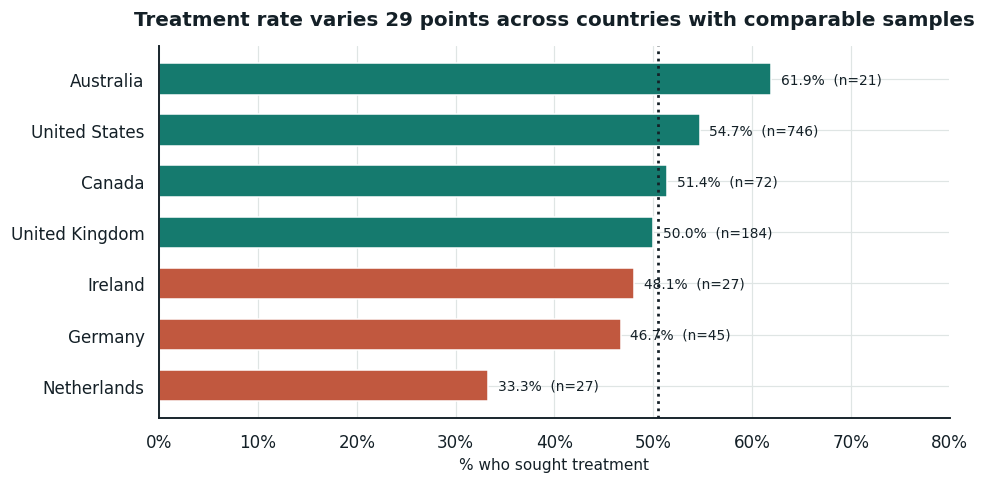

In [33]:
big = df["Country"].value_counts()
big = big[big >= 20].index
cd = treatment_rate(df[df["Country"].isin(big)], "Country")
fig, ax = plt.subplots(figsize=(9, 4.5))
cols = [TEAL if r >= 50 else CORAL for r in cd["rate"]]
ax.barh(cd["Country"][::-1], cd["rate"][::-1], color=cols[::-1], height=0.62)
ax.axvline(df["Treated"].mean()*100, color=INK, linestyle=":", linewidth=1.8)
ax.set_title("Treatment rate varies 29 points across countries with comparable samples")
ax.set_xlabel("% who sought treatment")
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xlim(0, 80)
for i, (_, r) in enumerate(cd[::-1].iterrows()):
    ax.text(r["rate"] + 1, i, f"{r['rate']}%  (n={int(r['n'])})", va="center", fontsize=9)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Filtering to countries with at least 20 responses before ranking is the point of this chart — an unfiltered country ranking would be topped by countries with two respondents and would be pure noise dressed up as a finding.

##### 2. What is/are the insight(s) found from the chart?

Australia leads at 62% and the Netherlands trails at 33%, with the US at 55% and the UK at 50%. Even after filtering, the smaller samples (21-45 people) carry wide error bars, so the safe reading is 'US and Australia high, continental Europe lower', not a precise league table.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** a multinational cannot run one global playbook — local healthcare access and stigma differ enough to change the baseline by 29 points. **Negative:** acting on a 21-person Australian sample would be overfitting, and the analysis has no data at all for most of the world, including all of Asia at meaningful volume.

#### Chart - 20 - Age Group and Remote Work

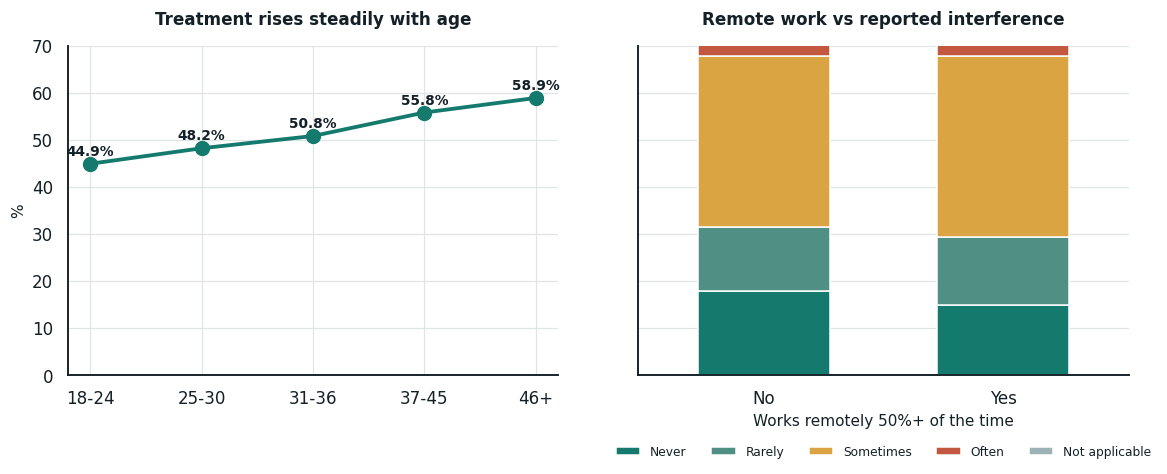

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)
ag = treatment_rate(df, "Age_Group").sort_values("Age_Group")
axes[0].plot(ag["Age_Group"].astype(str), ag["rate"], color=TEAL, marker="o",
             linewidth=2.5, markersize=9)
axes[0].set_title("Treatment rises steadily with age", fontsize=11)
for i, (_, r) in enumerate(ag.iterrows()):
    axes[0].text(i, r["rate"]+1.8, f"{r['rate']}%", ha="center", fontweight="bold", fontsize=9)

rw = pd.crosstab(df["remote_work"], df["work_interfere"], normalize="index")*100
rw = rw.reindex(columns=INTERFERE_ORDER)
rw.plot(kind="bar", stacked=True, ax=axes[1], width=0.55,
        color=[TEAL, "#4F8F84", AMBER, CORAL, MIST])
axes[1].set_title("Remote work vs reported interference", fontsize=11)
axes[1].set_xlabel("Works remotely 50%+ of the time")
axes[1].legend(ncol=5, loc="upper center", bbox_to_anchor=(0.5, -0.18), fontsize=8)
axes[1].tick_params(axis="x", rotation=0)
axes[0].set_ylabel("%")
axes[0].set_ylim(0, 70)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Two related bivariate questions share a figure because both are secondary checks rather than headline findings — giving each a full-width chart would overstate their importance relative to Charts 12-14.

##### 2. What is/are the insight(s) found from the chart?

Treatment climbs monotonically with age, from 45% (18-24) to 59% (46+). Remote work barely moves anything: 53% of remote workers have sought treatment versus 50% of office workers, and the interference distributions are nearly identical. Remote work is neither the cause nor the cure people assumed it was.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** the age gradient means the youngest employees — the largest group in tech — are the least likely to seek help, which makes onboarding the natural moment to normalise it. **Negative:** the flat remote-work result is a useful null: a company hoping a remote policy will improve mental-health outcomes on its own has no support for that here.

#### Chart - 21 - Does the Employer Take Mental Health Seriously?

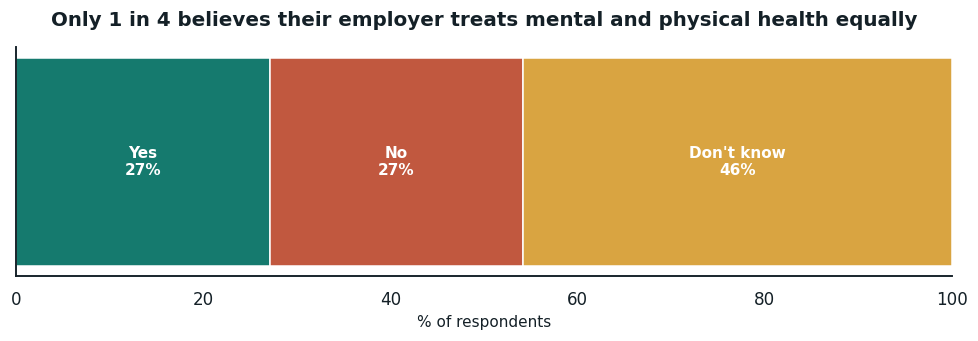

Employer_Support_Score  False  True 
mental_vs_physical                  
Don't know               49.5   33.6
No                       28.8   21.0
Yes                      21.7   45.5


In [35]:
mv = df["mental_vs_physical"].value_counts(normalize=True) * 100
mv = mv.reindex(["Yes", "No", "Don't know"])
fig, ax = plt.subplots(figsize=(9, 3.2))
left = 0
for idx, color in zip(mv.index, [TEAL, CORAL, AMBER]):
    ax.barh([""], mv[idx], left=left, color=color, height=0.5, label=idx)
    ax.text(left + mv[idx]/2, 0, f"{idx}\n{mv[idx]:.0f}%", ha="center", va="center",
            color="white", fontweight="bold")
    left += mv[idx]
ax.set_xlim(0, 100)
ax.set_yticks([])
ax.grid(False)
ax.set_xlabel("% of respondents")
ax.set_title("Only 1 in 4 believes their employer treats mental and physical health equally")
plt.tight_layout()
plt.show()

print(pd.crosstab(df["mental_vs_physical"], df["Employer_Support_Score"] >= 3,
                  normalize="columns").round(3) * 100)

##### 1. Why did you pick the specific chart?

A single full-width stacked bar is used because this is one question with three shares — a proportion bar states it in one line of ink without the visual overhead of axes and gridlines that carry no information here.

##### 2. What is/are the insight(s) found from the chart?

Only 27% say yes, 46% say they don't know, and 27% say no outright. The cross-tab shows the 'yes' share doubles — from 22% to 46% — at companies scoring 3+ on the support score. Belief tracks visible action, but even there it stays a minority view.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** perceived parity is a measurable KPI that an employer can track year over year, and it responds to real support. **Negative:** the 46% 'don't know' is a credibility problem — a company that announces parity without changing behaviour will move people from 'don't know' to 'no', which is worse than where it started.

#### Chart - 22 - Openness Score vs Treatment

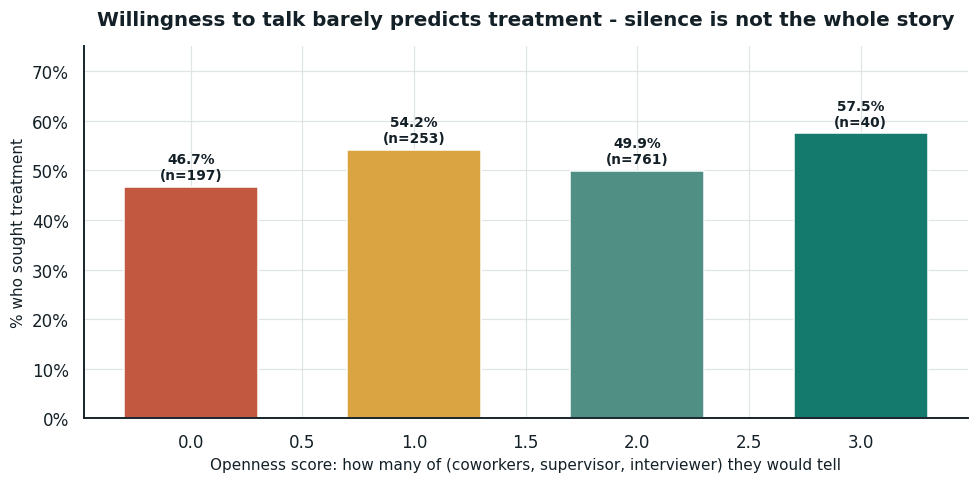

In [36]:
op = treatment_rate(df, "Openness_Score").sort_values("Openness_Score")
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(op["Openness_Score"], op["rate"], color=[CORAL, AMBER, "#4F8F84", TEAL], width=0.6)
for _, r in op.iterrows():
    ax.text(r["Openness_Score"], r["rate"]+1.5, f"{r['rate']}%\n(n={int(r['n'])})",
            ha="center", fontweight="bold", fontsize=9)
ax.set_title("Willingness to talk barely predicts treatment - silence is not the whole story")
ax.set_xlabel("Openness score: how many of (coworkers, supervisor, interviewer) they would tell")
ax.set_ylabel("% who sought treatment")
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_ylim(0, 75)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

The second engineered score gets the same treatment as the first so the two are directly comparable — and this chart is kept even though the result is weak, because a null result is information and hiding it would misrepresent the analysis.

##### 2. What is/are the insight(s) found from the chart?

The rate runs 47% / 54% / 50% / 58% across scores 0 to 3 — an 11-point spread with no clean monotonic trend, against 33 points for the employer support score. Being willing to talk at work is only weakly related to getting care.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** it protects the budget from being spent on the wrong thing. 'Awareness weeks' aimed at making people talk more are associated with far less movement than structural supports, so the ordering of spend matters. **Negative:** openness still matters for culture and for the disclosure gap in Chart 16 — this chart argues against over-claiming it, not against doing it.

### **Multivariate Analysis** — how do the variables move together?

#### Chart - 23 - Correlation Heatmap

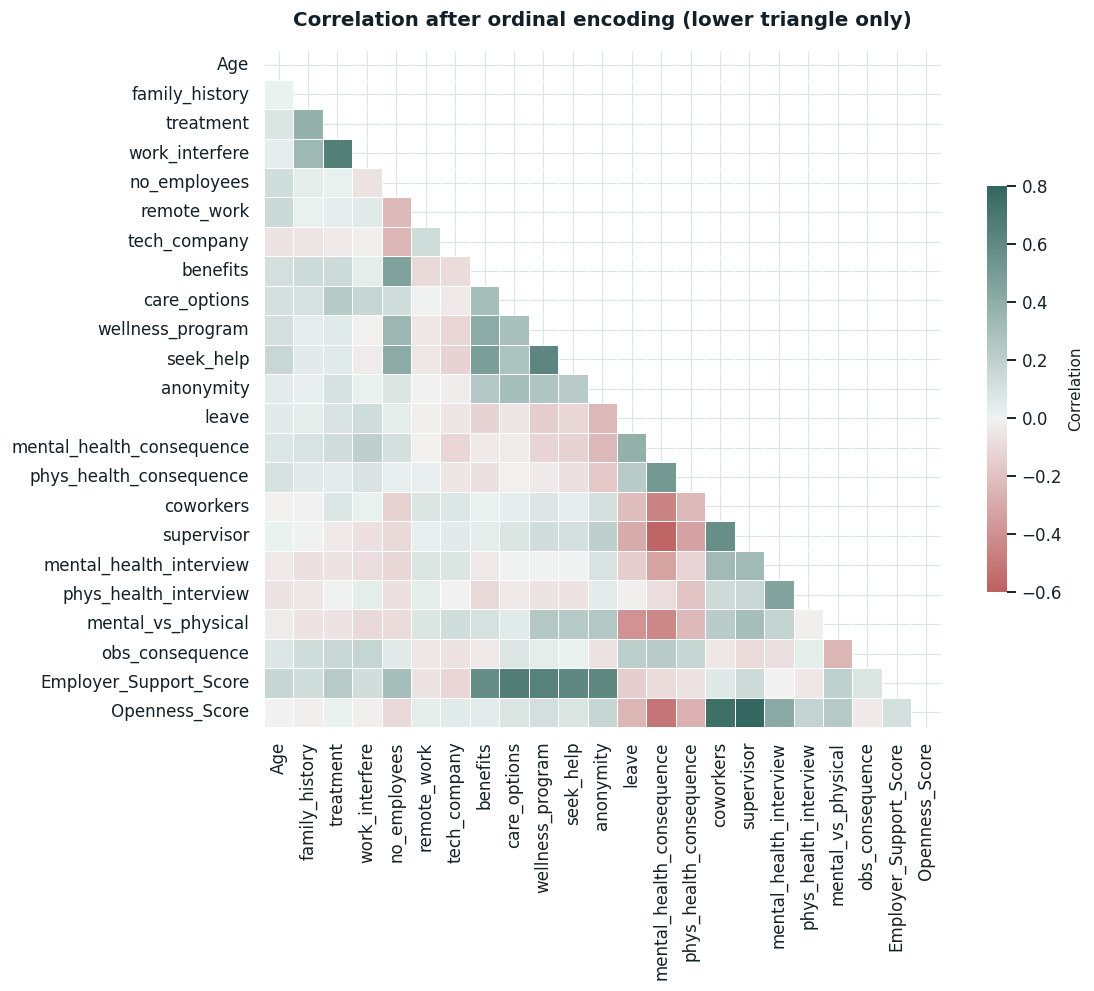

Strongest correlates of `treatment`:
work_interfere               0.654
family_history               0.377
care_options                 0.235
Employer_Support_Score       0.228
obs_consequence              0.153
benefits                     0.140
mental_health_consequence    0.126
anonymity                    0.100


In [37]:
enc = encode_for_correlation(df)
corr = enc.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, mask=mask, cmap=sns.diverging_palette(12, 175, s=70, l=40, as_cmap=True),
            center=0, vmin=-0.6, vmax=0.8, square=True, linewidths=0.6, linecolor="white",
            cbar_kws={"shrink": 0.6, "label": "Correlation"}, ax=ax)
ax.set_title("Correlation after ordinal encoding (lower triangle only)", pad=16)
plt.tight_layout()
plt.show()

print("Strongest correlates of `treatment`:")
print((corr["treatment"].drop("treatment").sort_values(key=abs, ascending=False)
       .head(8).round(3).to_string()))

##### 1. Why did you pick the specific chart?

A heatmap is the only practical way to read 23 variables against each other at once, and it is masked to the lower triangle because the upper half is a mirror image — showing both would double the ink for zero extra information. Encoding was required first: correlating raw Yes/No strings is meaningless.

##### 2. What is/are the insight(s) found from the chart?

`work_interfere` (0.65) and `family_history` (0.38) dominate, followed by `care_options` (0.24) and `Employer_Support_Score` (0.23). The five employer-support columns correlate strongly with *each other* — companies tend to offer all or none — which means they are not independent levers and a regression on them would suffer from multicollinearity.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** it ranks the levers, and confirms the awareness finding from Chart 13 survives when every variable is considered together. **Negative:** the clustering of support columns means a company cannot expect the effects to add up independently; buying a fifth support on top of four is unlikely to deliver a fifth of the total effect — consistent with the plateau seen in Chart 14.

#### Chart - 24 - Pair Plot — Age, Support and Openness by Treatment

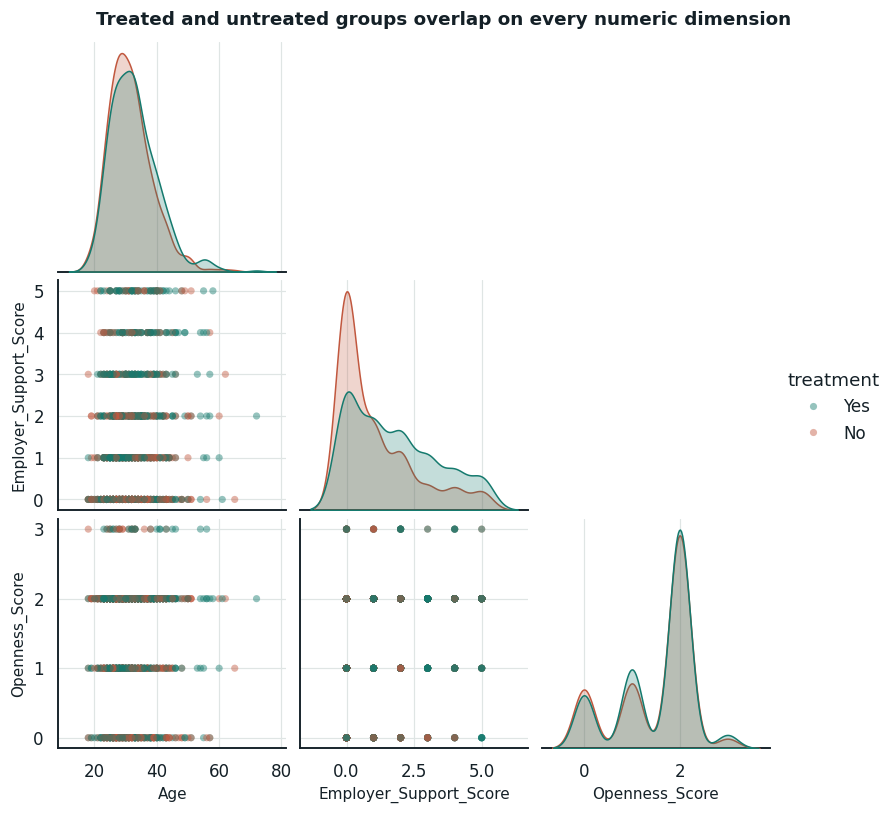

In [38]:
pp = df[["Age", "Employer_Support_Score", "Openness_Score", "treatment"]].copy()
g = sns.pairplot(pp, hue="treatment", palette={"Yes": TEAL, "No": CORAL},
                 diag_kind="kde", plot_kws=dict(alpha=0.45, s=22, edgecolor="none"),
                 height=2.4, corner=True)
g.figure.suptitle("Treated and untreated groups overlap on every numeric dimension",
                  y=1.02, fontweight="bold")
plt.show()

##### 1. Why did you pick the specific chart?

The pair plot is the standard way to inspect every pairwise relationship among the numeric variables at once, with the diagonal showing each distribution split by outcome. The corner layout drops the redundant mirrored half.

##### 2. What is/are the insight(s) found from the chart?

The KDEs on the diagonal tell the real story: the treated group sits slightly right on Age and clearly right on Employer_Support_Score, but the two distributions overlap heavily everywhere. No single numeric variable separates treated from untreated — the signal in this dataset is categorical (family history, work interference), not continuous.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** it sets realistic expectations for any predictive model built on this data — accuracy will come from the categorical answers, not from age. **Negative:** it also rules out simple numeric targeting rules like 'focus on employees over 40', which would look attractive but has no support here.

#### Chart - 25 - Multivariate — Treatment Rate by Company Size × Support Level

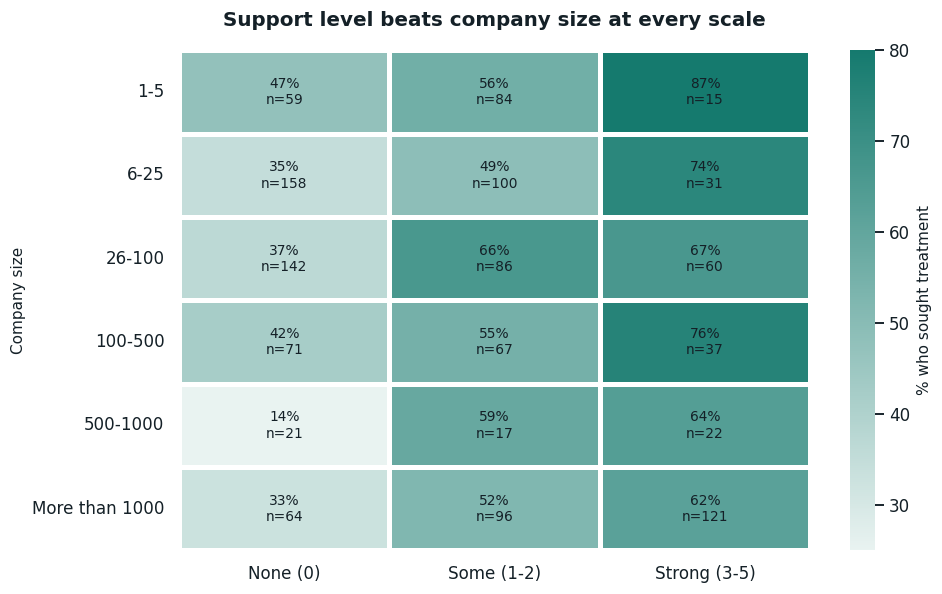

In [39]:
d = df.copy()
d["Support level"] = pd.cut(d["Employer_Support_Score"], bins=[-1, 0, 2, 5],
                            labels=["None (0)", "Some (1-2)", "Strong (3-5)"])
piv = (d.pivot_table(index="no_employees", columns="Support level",
                     values="Treated", aggfunc="mean", observed=True)
       .reindex(COMPANY_SIZE_ORDER) * 100)
cnt = d.pivot_table(index="no_employees", columns="Support level",
                    values="Treated", aggfunc="size", observed=True).reindex(COMPANY_SIZE_ORDER)
annot = piv.round(0).astype("Int64").astype(str) + "%\nn=" + cnt.astype("Int64").astype(str)

fig, ax = plt.subplots(figsize=(9, 5.5))
sns.heatmap(piv, annot=annot, fmt="", cmap=sns.light_palette(TEAL, as_cmap=True),
            linewidths=2, linecolor="white", vmin=25, vmax=80,
            cbar_kws={"label": "% who sought treatment"}, ax=ax,
            annot_kws={"fontsize": 9, "color": INK})
ax.set_title("Support level beats company size at every scale", pad=16)
ax.set_xlabel("")
ax.set_ylabel("Company size")
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A pivoted heatmap holds three variables at once — size on one axis, support on the other, outcome in the colour — and annotating each cell with its own sample size keeps the reader honest about which cells are thin enough to ignore.

##### 2. What is/are the insight(s) found from the chart?

Reading left to right, treatment rises in almost every row: the support gradient holds at every company size. Reading top to bottom within a column, size does very little. A 6-25 person startup with strong support outperforms a 1000+ enterprise with none. Some cells (500-1000, strong support) are single-digit and should not be read.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** this is the argument a small company needs — it does not have to grow into good mental-health outcomes; three well-communicated supports get it there now. **Negative:** the thin cells mean the pattern is directional rather than precise, and the whole grid remains correlational: firms that support their staff may differ in other ways this survey never asked about.

## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?

The objective was a ranked list of changes most associated with employees actually seeking
treatment. Ordered by the size of the association in this data against the cost of doing it:

**1. Publish what already exists (largest effect, near-zero cost).**
The gap between "we have benefits" and "I know what my care options are" is worth 30 points of
treatment rate (Chart 13), and 25% of people cannot say whether they have benefits at all
(Chart 8). One plain-language page — what is covered, how to use it, who to ask — addresses the
single biggest block of uncertainty in the survey. Repeat it at onboarding, where the youngest and
least-likely-to-seek-help cohort is sitting (Chart 20).

**2. Guarantee anonymity in writing.**
65% do not know whether their anonymity is protected; those who do know seek treatment at 61%
versus 45% (Chart 18). This is a policy paragraph, not a programme.

**3. Name mental health in the leave policy.**
45% cannot say whether they could take mental-health leave (Chart 9), and people who find leave
*difficult* have the highest treatment rates — they are ill enough to have tried. Removing the
ambiguity moves the decision from guesswork to a known process.

**4. Train supervisors, do not just run awareness weeks.**
Supervisors are the most-trusted audience in the company (Chart 17), while general openness barely
predicts treatment at all (Chart 22). Spend on the channel that works: managers who can respond to
a disclosure without escalating it.

**5. Target the quiet majority.**
Men are 79% of this workforce and seek treatment 23 points less often than women (Chart 10), and
people with no family history sit 39 points below those who have one (Chart 11). Both groups are
large and both are under-treated relative to plausible prevalence.

**6. Stop at three supports and communicate them well.**
The treatment rate plateaus after three of the five supports (Chart 14) and the support columns are
heavily inter-correlated (Chart 23). Buying a fourth and fifth programme is not where the remaining
gain is; execution on the first three is.

**What to measure.** Track the share of employees who can correctly name the care options, the
share who know the anonymity policy, and the `mental_vs_physical` parity question as an annual
pulse. All three are cheap to survey and all three move before treatment rates do.

**The honest caveat.** Every relationship here is correlational and self-reported, from a
self-selected 2014 sample that is 79% male and 60% American. It is strong enough to rank priorities
and to justify a pilot; it is not strong enough to promise a specific percentage-point return.

# **Conclusion**

Half of the 1,251 tech workers in this survey have sought mental-health treatment. That single
number breaks the assumption the industry was operating on in 2014 — that this was an edge case
affecting a handful of employees — and it reframes every policy decision that follows.

Three findings carry the analysis. First, treatment is **reactive**: it tracks work interference
almost perfectly (r = 0.65), climbing from 14% among those whose condition never affects work to
85% among those it affects often. People wait until their job is at stake. Second, the strongest
employer lever is **awareness, not provision** — knowing your care options is associated with a
30-point difference in treatment versus a 16-point difference for merely having benefits, and the
most common answer across all five support questions is "I don't know". Third, **stigma survives
policy**: 80% would not mention mental health in an interview versus 40% for physical health, and
only 27% believe their employer treats the two equally.

The company-size analysis explains where enterprise spend leaks. Large firms provide far more
support on paper yet see barely higher treatment rates than five-person startups, and the
multivariate view shows that a small company with three well-communicated supports outperforms a
large one with none. The constraint is not budget. It is whether the employee knows what exists,
believes it is confidential, and trusts their manager to handle it.

The recommendations follow directly and are ordered by effect-per-rupee: publish what already
exists, guarantee anonymity in writing, name mental health in the leave policy, train supervisors,
and target the two large under-treated groups — men, and people with no family history of mental
illness.

The limits are real and worth restating. This is a self-selected 2014 sample, 79% male and 60%
American, and every relationship in it is correlational. It is enough to rank priorities and design
a pilot. It is not enough to promise an outcome — which is itself the argument for measuring the
three pulse questions above, and re-running this analysis on the company's own data.

### ***Hurrah! You have successfully completed your EDA Capstone Project !!!***